In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib.metadata import version
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Mostrar versiones
print(f"Versión pandas: {version('pandas')}")
print(f"Versión matplotlib: {version('matplotlib')}")
print(f"Versión scikit-learn: {version('scikit-learn')}")

Versión pandas: 3.0.0
Versión matplotlib: 3.10.8
Versión scikit-learn: 1.8.0


In [3]:
data = pd.read_csv('./data/Datos Lab 1.csv')
data_test = pd.read_csv('./data/Datos Test Lab 1.csv', sep=';')

data = data.copy()

data.head()
data.sample(5)

data.shape

data.info()

data.describe()

nulos = ((data.isnull().sum()/data.shape[0])*100).sort_values(ascending=False)
print(nulos[nulos > 0])

duplicados = data.duplicated().sum()
print(f"Duplicados: {duplicados}")

<class 'pandas.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   str    
 1   Date of Service               1639 non-null   str    
 2   Sex                           1639 non-null   str    
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   str    
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   str    
 13  Diabetes Statu

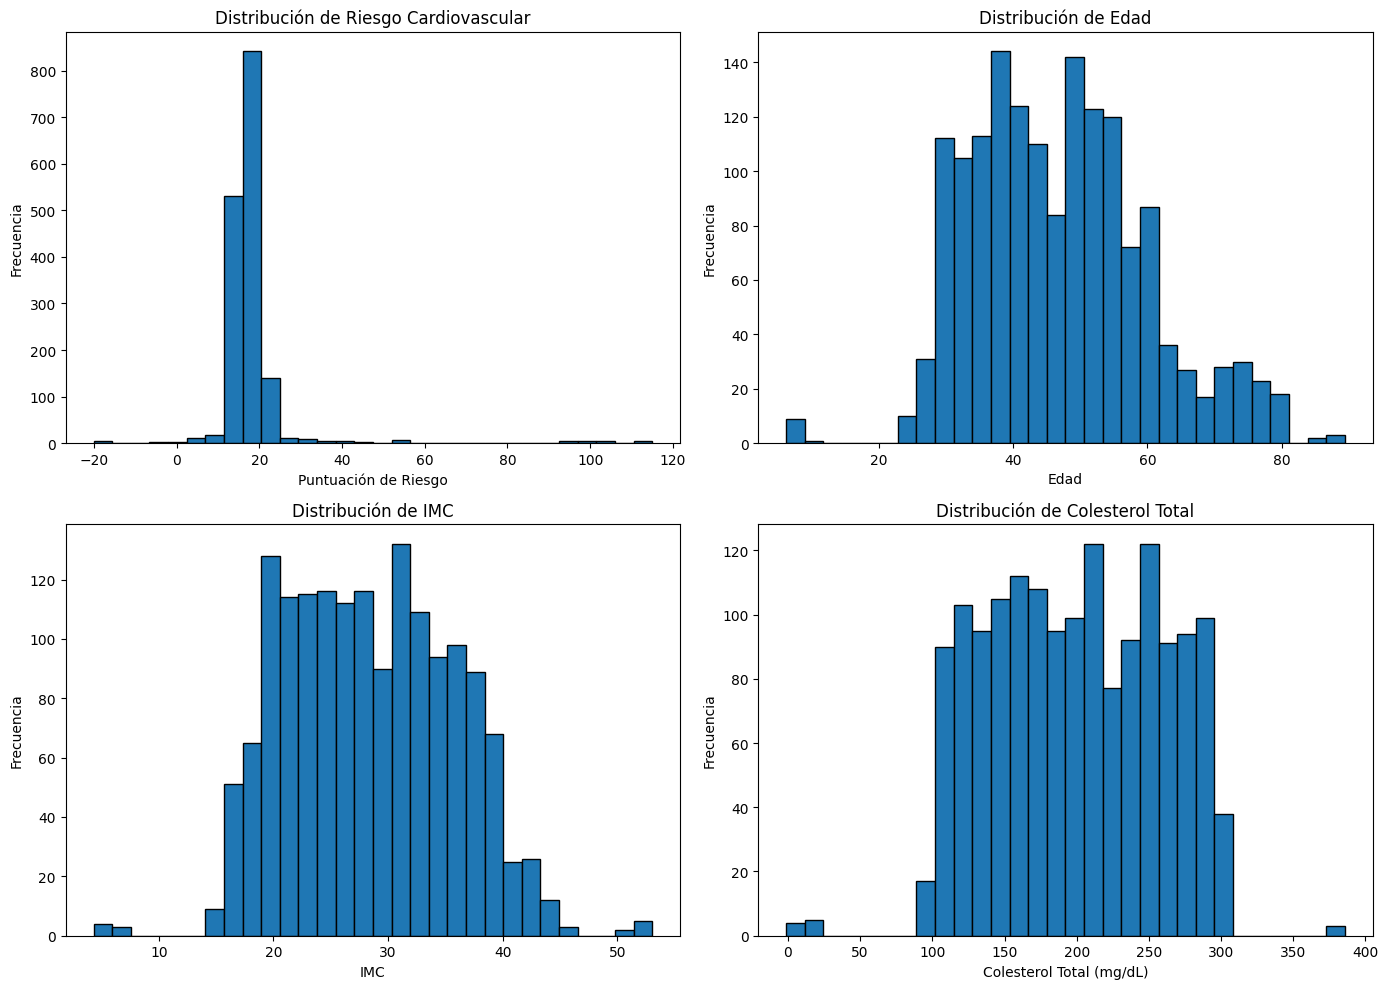

In [4]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

ejes[0, 0].hist(data['CVD Risk Score'].dropna(), bins=30, edgecolor='black')
ejes[0, 0].set_title('Distribución de Riesgo Cardiovascular')
ejes[0, 0].set_xlabel('Puntuación de Riesgo')
ejes[0, 0].set_ylabel('Frecuencia')

ejes[0, 1].hist(data['Age'].dropna(), bins=30, edgecolor='black')
ejes[0, 1].set_title('Distribución de Edad')
ejes[0, 1].set_xlabel('Edad')
ejes[0, 1].set_ylabel('Frecuencia')

ejes[1, 0].hist(data['BMI'].dropna(), bins=30, edgecolor='black')
ejes[1, 0].set_title('Distribución de IMC')
ejes[1, 0].set_xlabel('IMC')
ejes[1, 0].set_ylabel('Frecuencia')

ejes[1, 1].hist(data['Total Cholesterol (mg/dL)'].dropna(), bins=30, edgecolor='black')
ejes[1, 1].set_title('Distribución de Colesterol Total')
ejes[1, 1].set_xlabel('Colesterol Total (mg/dL)')
ejes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Correlacion con riesgo cardiovascular
CVD Risk Score                  1.000000
BMI                             0.133475
Systolic BP                     0.086767
Total Cholesterol (mg/dL)       0.053244
Estimated LDL (mg/dL)           0.043440
Weight (kg)                     0.042471
Diastolic BP                    0.026218
Waist-to-Height Ratio           0.020090
Fasting Blood Sugar (mg/dL)     0.000947
Abdominal Circumference (cm)   -0.000946
Age                            -0.004056
HDL (mg/dL)                    -0.011412
Height (m)                     -0.015594
Height (cm)                    -0.023800
Name: CVD Risk Score, dtype: float64
Matriz de correlaciones - Variables numéricas


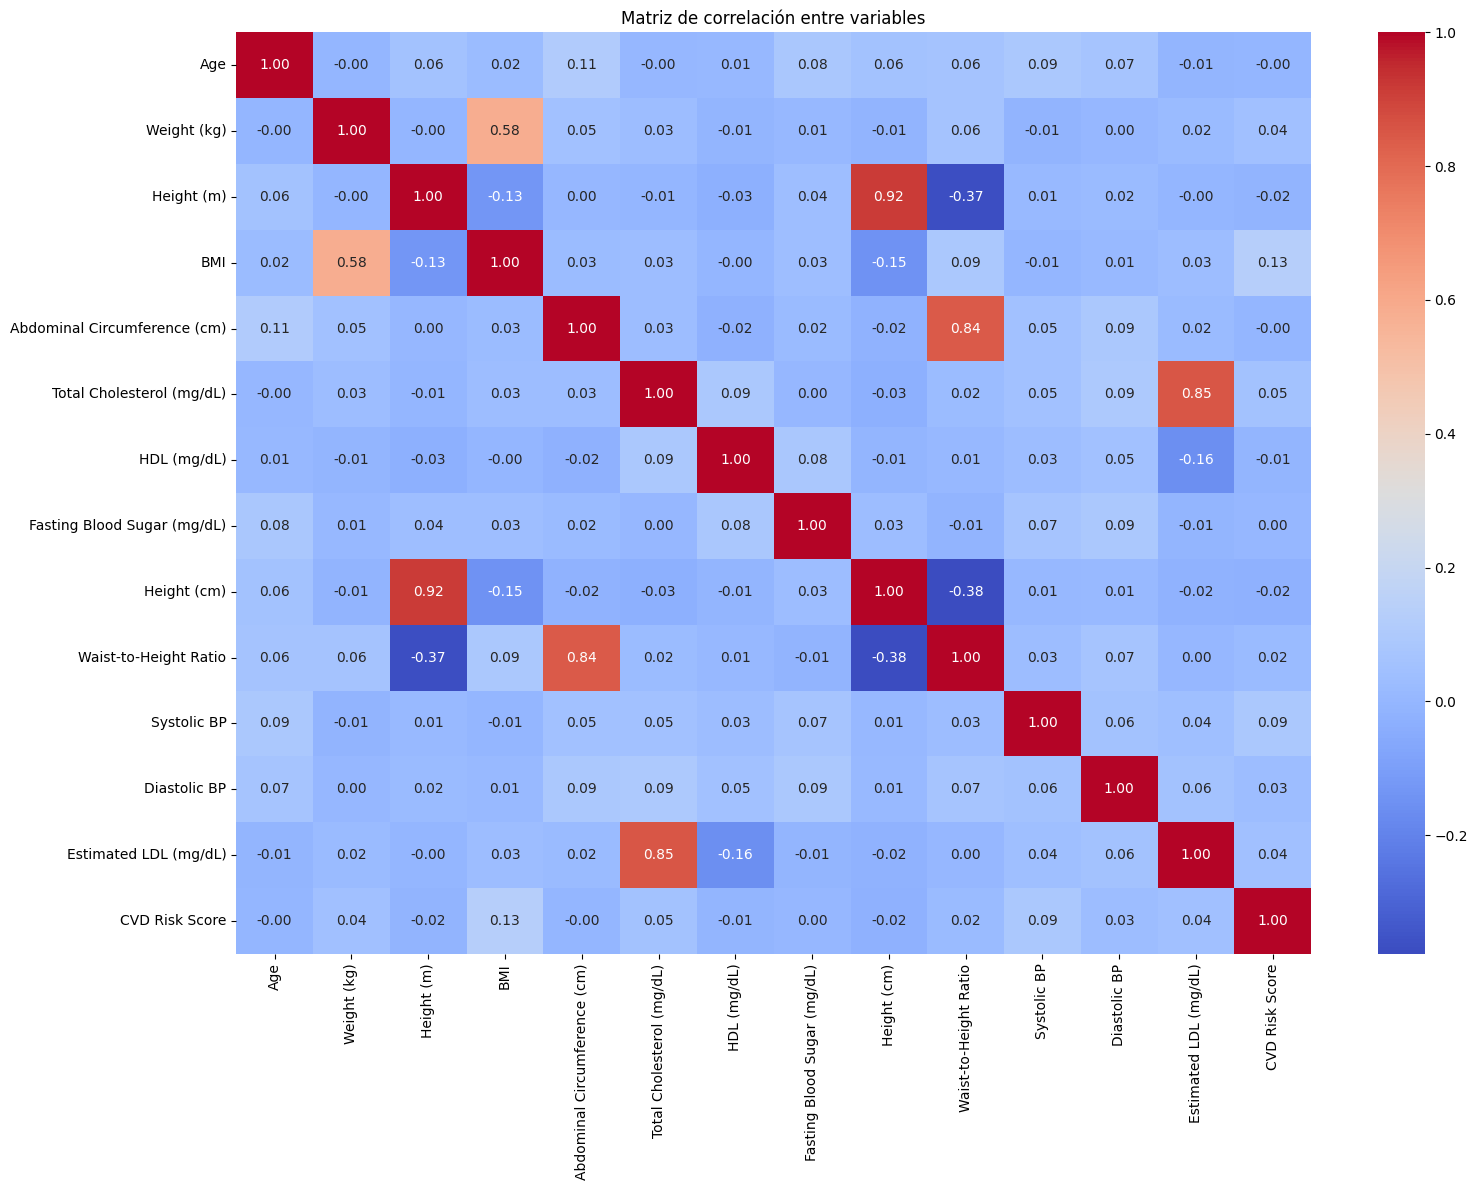

Estadísticas descriptivas
               Age  Weight (kg)   Height (m)          BMI  \
count  1571.000000  1566.000000  1578.000000  1586.000000   
mean     46.803186    85.666006     1.757439    28.424744   
std      13.039479    21.712504     0.118012     7.309275   
min       6.134000    13.261000     1.371000     4.317000   
25%      37.000000    67.100000     1.666500    22.600000   
50%      46.000000    86.314000     1.760000    28.000000   
75%      55.000000   104.801500     1.850000    33.963000   
max      89.420000   158.523000     2.146000    53.028000   

       Abdominal Circumference (cm)  Total Cholesterol (mg/dL)  HDL (mg/dL)  \
count                   1578.000000                1571.000000  1557.000000   
mean                      91.538861                 199.043673    56.183558   
std                       13.427985                  59.388670    16.721702   
min                       49.542000                  -1.256000     0.008000   
25%                       79.

In [5]:
print("Correlacion con riesgo cardiovascular")
correlaciones = data.corr(numeric_only=True)['CVD Risk Score'].sort_values(ascending=False)
print(correlaciones)

print("Matriz de correlaciones - Variables numéricas")
plt.figure(figsize=(16, 12))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.show()

print("Estadísticas descriptivas")
print(data.describe())

In [6]:
print("RESUMEN DEL DATASET")
print(f"Cantidad de filas: {data.shape[0]}")
print(f"Cantidad de columnas: {data.shape[1]}")
variables_numericas = data.select_dtypes(include=['float64', 'int64']).shape[1]
variables_categoricas = data.select_dtypes(include=['object']).shape[1]
print(f"Cantidad de variables numéricas: {variables_numericas}")
print(f"Cantidad de variables categóricas: {variables_categoricas}")

RESUMEN DEL DATASET
Cantidad de filas: 1639
Cantidad de columnas: 24
Cantidad de variables numéricas: 14
Cantidad de variables categóricas: 10


In [7]:
data = pd.read_csv('./data/Datos Lab 1.csv')
data = data.copy()

print("Registros iniciales:", data.shape[0])

duplicados = data.duplicated().sum()
print(f"Duplicados: {duplicados}")

data = data.drop_duplicates()
print(f"Registros después de eliminar duplicados: {data.shape[0]}")

nulos = ((data.isnull().sum()/data.shape[0])*100).sort_values(ascending=False)
nulos = nulos[nulos > 0]
print(f"Valores nulos: {nulos}")

data = data.dropna(subset=['CVD Risk Score'])
print(f"Registros después de eliminar nulos en CVD Risk Score: {data.shape[0]}")

print("Sección de variables:")
variables_objetivo = 'CVD Risk Score'
variables_excluir = ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
print(f"Variables excluidas: {variables_excluir}")

X = data.drop(columns=variables_excluir + [variables_objetivo])
y = data[variables_objetivo]

print(f"Variables seleccionadas para el modelo: {X.shape[1]}")
print(X.columns.tolist())

variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X.select_dtypes(include=['object']).columns.tolist()
print(f"Variables numericas ({len(variables_numericas)}): {variables_numericas}")
print(f"Variables categoricas ({len(variables_categoricas)}): {variables_categoricas}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]} ({100*X_train.shape[0]/X.shape[0]:.1f}%)")
print(f"Tamaño conjunto prueba: {X_test.shape[0]} ({100*X_test.shape[0]/X.shape[0]:.1f}%)")

Registros iniciales: 1639
Duplicados: 151
Registros después de eliminar duplicados: 1488
Valores nulos: HDL (mg/dL)                     4.905914
Diastolic BP                    4.838710
Waist-to-Height Ratio           4.569892
Weight (kg)                     4.502688
Total Cholesterol (mg/dL)       4.166667
Age                             4.099462
Height (cm)                     4.099462
Systolic BP                     3.763441
Height (m)                      3.629032
Abdominal Circumference (cm)    3.494624
Estimated LDL (mg/dL)           3.427419
Fasting Blood Sugar (mg/dL)     3.293011
BMI                             3.225806
CVD Risk Score                  1.881720
dtype: float64
Registros después de eliminar nulos en CVD Risk Score: 1460
Sección de variables:
Variables excluidas: ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
Variables seleccionadas para el modelo: 17
['Sex', 'Age', 'Weight (kg)', 'BMI', 'Abdominal Circumf

In [8]:
print("Creación de pipeline")
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, variables_numericas),
        ('cat', transformador_categorico, variables_categoricas)
    ])

print("Verificador de datos preparados")
X_train_preparado = preprocesamiento.fit_transform(X_train)
X_test_preparado = preprocesamiento.transform(X_test)

print(f"Dimensiones de X_train preparado: {X_train_preparado.shape}")
print(f"Dimensiones de X_test preparado: {X_test_preparado.shape}")
print(f"Variables iniciales: {X.shape[1]}")
print(f"Variables finales: {X_train_preparado.shape[1]}")

Creación de pipeline
Verificador de datos preparados
Dimensiones de X_train preparado: (1095, 26)
Dimensiones de X_test preparado: (365, 26)
Variables iniciales: 17
Variables finales: 26


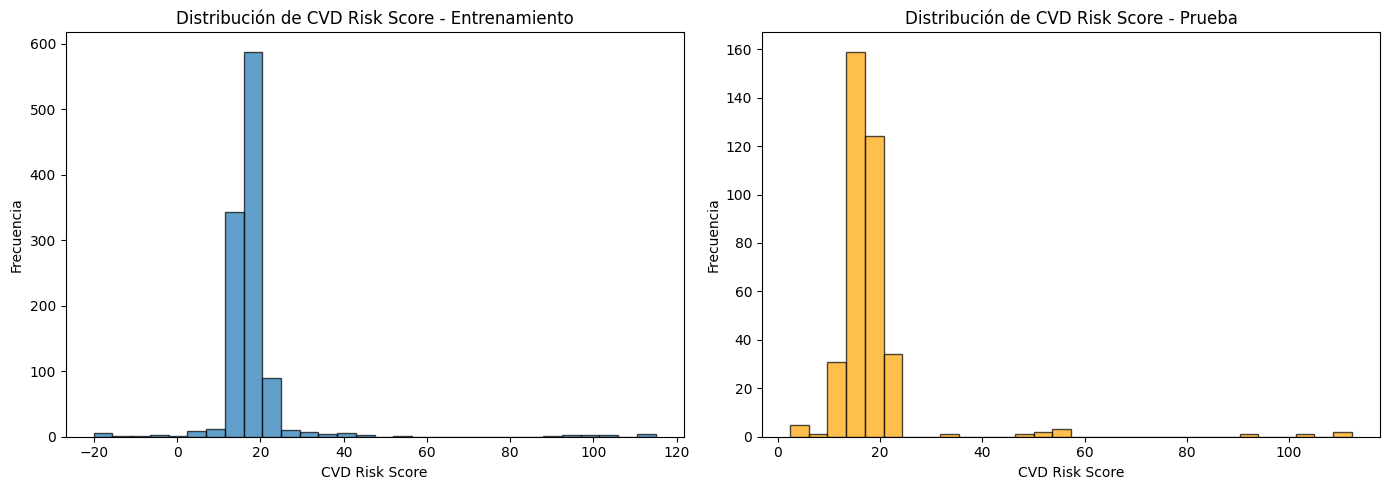

RESUMEN
Registros iniciales: 1611
Registros finales: 1460
Varibles finales: 17
Registros entrenamiento: 1095
Registros prueba: 365


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].hist(y_train, bins=30, edgecolor='black', alpha=0.7, label='Entrenamiento')
ejes[0].set_title('Distribución de CVD Risk Score - Entrenamiento')
ejes[0].set_xlabel('CVD Risk Score')
ejes[0].set_ylabel('Frecuencia')

ejes[1].hist(y_test, bins=30, edgecolor='black', alpha=0.7, color='orange', label='Prueba')
ejes[1].set_title('Distribución de CVD Risk Score - Prueba')
ejes[1].set_xlabel('CVD Risk Score')
ejes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("RESUMEN")
print(f"Registros iniciales: {data.shape[0] + duplicados}")
print(f"Registros finales: {X.shape[0]}")
print(f"Varibles finales: {X.shape[1]}")
print(f"Registros entrenamiento: {X_train.shape[0]}")
print(f"Registros prueba: {X_test.shape[0]}")

In [10]:
X_train_m1 = X_train[variables_numericas].copy()
X_test_m1 = X_test[variables_numericas].copy()

prep_m1 = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy='median')),
    ("escalador", StandardScaler())
])

X_train_prep_m1 = prep_m1.fit_transform(X_train_m1)
X_test_prep_m1 = prep_m1.transform(X_test_m1)

modelo1 = LinearRegression()
modelo1.fit(X_train_prep_m1, y_train)

y_pred_m1 = modelo1.predict(X_test_prep_m1)
rmse_m1 = np.sqrt(mean_squared_error(y_test, y_pred_m1))
mae_m1 = mean_absolute_error(y_test, y_pred_m1)
r2_m1 = r2_score(y_test, y_pred_m1)

m1_data = {
    "modelo": modelo1,
    "preprocesamiento": prep_m1,
    "variables_num": variables_numericas,
    "variables_cat": [],
    "rmse": rmse_m1,
    "r2": r2_m1
}

with open("modelo1.pkl", "wb") as f:
    pickle.dump(m1_data, f)
    
prep_m2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", MinMaxScaler())
        ]), variables_numericas),
        ("cat", Pipeline(steps=[
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificador", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), variables_categoricas)
    ])

X_train_prep_m2 = prep_m2.fit_transform(X_train)
X_test_prep_m2 = prep_m2.transform(X_test)

modelo2 = LinearRegression()
modelo2.fit(X_train_prep_m2, y_train)

y_pred_m2 = modelo2.predict(X_test_prep_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test, y_pred_m2))
mae_m2 = mean_absolute_error(y_test, y_pred_m2)
r2_m2 = r2_score(y_test, y_pred_m2)

print(f"Modelo 2 - Rendimiento:")
print(f"RMSE: {rmse_m2:.4f}")
print(f"MAE: {mae_m2:.4f}")
print(f"R²: {r2_m2:.4f}")
print()

m2_data = {
    "modelo": modelo2,
    "preprocesamiento": prep_m2,
    "variables_num": variables_numericas,
    "variables_cat": variables_categoricas,
    "rmse": rmse_m2,
    "r2": r2_m2
}

with open("modelo2.pkl", "wb") as f:
    pickle.dump(m2_data, f)
print("Modelo 2 guardado como 'modelo2.pkl'")

Modelo 2 - Rendimiento:
RMSE: 10.6407
MAE: 3.7073
R²: 0.0273

Modelo 2 guardado como 'modelo2.pkl'


In [11]:
with open('modelo1.pkl', 'rb') as f:
    m1_data = pickle.load(f)
    modelo1 = m1_data['modelo']
    prep1 = m1_data['preprocesamiento']
    var_num1 = m1_data['variables_num']
    var_cat1 = m1_data['variables_cat']
    
with open('modelo2.pkl', 'rb') as f:
    m2_data = pickle.load(f)
    modelo2 = m2_data['modelo']
    prep2 = m2_data['preprocesamiento']
    var_num2 = m2_data['variables_num']
    var_cat2 = m2_data['variables_cat']
    
X_train_prep1 = prep1.transform(X_train[var_num1])
X_test_prep1 = prep1.transform(X_test[var_num1])

X_test_sel2 = X_test[var_num2 + var_cat2]
X_test_prep2 = prep2.transform(X_test_sel2)

y_pred_m1 = modelo1.predict(X_test_prep1)
y_pred_m2 = modelo2.predict(X_test_prep2)

def calcular_metricas(y_true, y_pred, nombre_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {'Modelo': nombre_modelo, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

metricas_m1 = calcular_metricas(y_test, y_pred_m1, 'Modelo 1 - Baseline')
metricas_m2 = calcular_metricas(y_test, y_pred_m2, 'Modelo 2 - Alternativas')

tabla_comparativa = pd.DataFrame([metricas_m1, metricas_m2])

print("Tabla comparativa de modelos")
print(tabla_comparativa.to_string(index=False))

tabla_comparativa.to_csv('comparacion_modelos.csv', index=False)
print("Tabla comparativa guardada como 'comparacion_modelos.csv'")

print(f"""
RMSE (Error Cuadrático Medio):
  - Mide el error promedio en unidades de CVD Risk Score
  - Penaliza más los errores grandes
  - Modelo 1 RMSE: {metricas_m1['RMSE']:.4f} (menor = mejor)
  - Modelo 2 RMSE: {metricas_m2['RMSE']:.4f}

MAE (Error Absoluto Medio):
  - Error promedio absoluto en unidades de CVD Risk Score
  - Interpretación directa: diferencia promedio en predicciones
  - Modelo 1 MAE: {metricas_m1['MAE']:.4f} (menor = mejor)
  - Modelo 2 MAE: {metricas_m2['MAE']:.4f}

R² (Coeficiente de Determinación):
  - Proporción de varianza en y explicada por el modelo
  - Rango: 0 a 1, donde 1 es perfecto
  - Modelo 1 R²: {metricas_m1['R2']:.4f} ({100*metricas_m1['R2']:.1f}% de varianza explicada)
  - Modelo 2 R²: {metricas_m2['R2']:.4f} ({100*metricas_m2['R2']:.1f}% de varianza explicada)
""")

mejor_idx = tabla_comparativa['R2'].idxmax()
mejor_fila = tabla_comparativa.loc[mejor_idx]
print(f"El mejor modelo es: {mejor_fila['Modelo']}")
print(f"  RMSE: {mejor_fila['RMSE']:.4f}")
print(f"  MAE: {mejor_fila['MAE']:.4f}")
print(f"  R²: {mejor_fila['R2']:.4f}")

Tabla comparativa de modelos
                 Modelo      RMSE      MAE       R2
    Modelo 1 - Baseline 10.765521 3.683505 0.004376
Modelo 2 - Alternativas 10.640715 3.707346 0.027326
Tabla comparativa guardada como 'comparacion_modelos.csv'

RMSE (Error Cuadrático Medio):
  - Mide el error promedio en unidades de CVD Risk Score
  - Penaliza más los errores grandes
  - Modelo 1 RMSE: 10.7655 (menor = mejor)
  - Modelo 2 RMSE: 10.6407

MAE (Error Absoluto Medio):
  - Error promedio absoluto en unidades de CVD Risk Score
  - Interpretación directa: diferencia promedio en predicciones
  - Modelo 1 MAE: 3.6835 (menor = mejor)
  - Modelo 2 MAE: 3.7073

R² (Coeficiente de Determinación):
  - Proporción de varianza en y explicada por el modelo
  - Rango: 0 a 1, donde 1 es perfecto
  - Modelo 1 R²: 0.0044 (0.4% de varianza explicada)
  - Modelo 2 R²: 0.0273 (2.7% de varianza explicada)

El mejor modelo es: Modelo 2 - Alternativas
  RMSE: 10.6407
  MAE: 3.7073
  R²: 0.0273


In [12]:
tabla_comparativa = pd.DataFrame({
    "Modelo": ["Modelo 1 - Baseline", "Modelo 2 - Alternativas"],
    "Variables": [
        f"{len(variables_numericas)} numéricas",
        f"{len(variables_numericas)} numéricas + {len(variables_categoricas)} categóricas"
    ],
    "Estrategia Prep.": ["SimpleImputer + StandardScaler", "SimpleImputer + MinMaxScaler + OneHotEncoder"],
    "RMSE": [rmse_m1, rmse_m2],
    "MAE": [mae_m1, mae_m2],
    "R²": [r2_m1, r2_m2]
})

print(tabla_comparativa.to_string(index=False))
print()

tabla_comparativa.to_csv("comparacion_modelos.csv", index=False, sep=";")
print("Tabla guardada como 'comparacion_modelos.csv'")
print()

mejor_idx = tabla_comparativa['R²'].idxmax()
mejor_modelo_nombre = tabla_comparativa.loc[mejor_idx, "Modelo"]
mejor_rmse = tabla_comparativa.loc[mejor_idx, "RMSE"]
mejor_r2 = tabla_comparativa.loc[mejor_idx, "R²"]

print(f"Mejor Modelo: {mejor_modelo_nombre}")
print(f"RMSE: {mejor_rmse:.4f}")
print(f"R²: {mejor_r2:.4f}")

                 Modelo                    Variables                             Estrategia Prep.      RMSE      MAE       R²
    Modelo 1 - Baseline                 11 numéricas               SimpleImputer + StandardScaler 10.765521 3.683505 0.004376
Modelo 2 - Alternativas 11 numéricas + 6 categóricas SimpleImputer + MinMaxScaler + OneHotEncoder 10.640715 3.707346 0.027326

Tabla guardada como 'comparacion_modelos.csv'

Mejor Modelo: Modelo 2 - Alternativas
RMSE: 10.6407
R²: 0.0273


Top 15 variables más importantes:
                        Variable  Coeficiente  Valor Absoluto
                             BMI    10.951246       10.951246
                     Systolic BP     4.792359        4.792359
                     Weight (kg)    -4.128665        4.128665
       Total Cholesterol (mg/dL)     3.934521        3.934521
                             Age    -3.925300        3.925300
  Blood Pressure Category_Normal    -2.209258        2.209258
           Waist-to-Height Ratio    -1.671207        1.671207
           Estimated LDL (mg/dL)    -1.405424        1.405424
               Diabetes Status_N    -1.284148        1.284148
               Diabetes Status_Y     1.284148        1.284148
                     HDL (mg/dL)    -1.158117        1.158117
Blood Pressure Category_Elevated     1.008935        1.008935
                    Diastolic BP    -0.849142        0.849142
     Physical Activity Level_Low    -0.729680        0.729680
Physical Activity Level_Moderate    

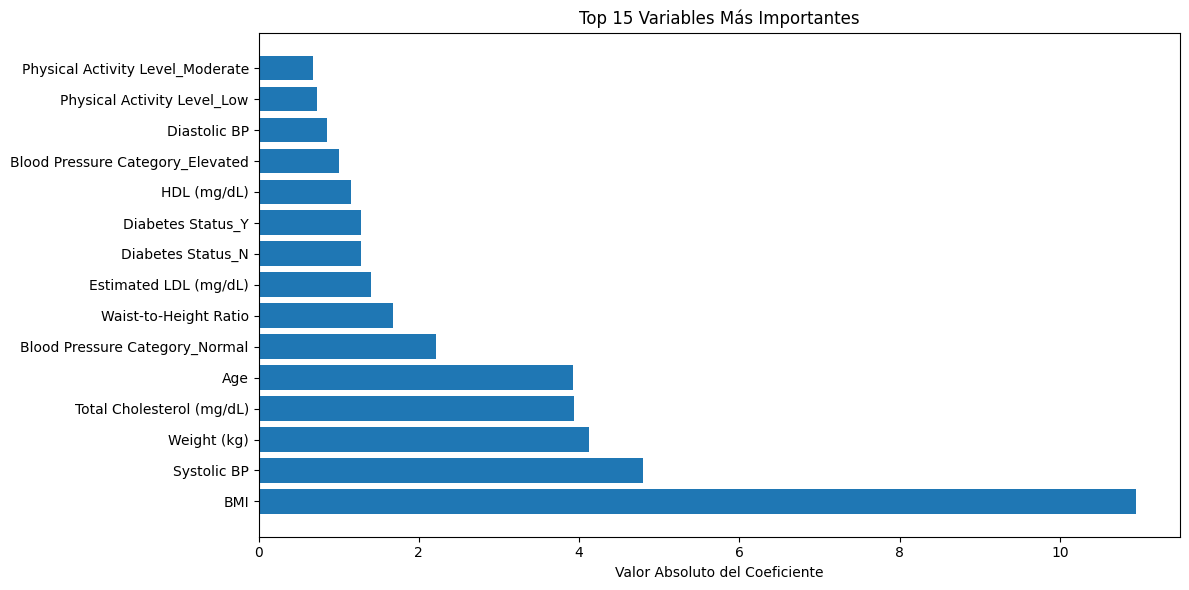

In [13]:
if mejor_idx == 0:
    mejor_mod = modelo1
    nombres_features = variables_numericas
else:
    mejor_mod = modelo2
    encoder = prep_m2.named_transformers_["cat"].named_steps["codificador"]
    feature_names_cat = []
    for i, cat_var in enumerate(variables_categoricas):
        categories = encoder.categories_[i]
        feature_names_cat.extend([f"{cat_var}_{cat}" for cat in categories])
    nombres_features = variables_numericas + feature_names_cat
    
coeficientes = mejor_mod.coef_
intercepto = mejor_mod.intercept_

importancia_vars = pd.DataFrame({
    "Variable": nombres_features,
    "Coeficiente": coeficientes,
    "Valor Absoluto": np.abs(coeficientes)
}).sort_values("Valor Absoluto", ascending=False)

print("Top 15 variables más importantes:")
print(importancia_vars.head(15).to_string(index=False))
print()
print(f"Intercepto (constante): {intercepto:.4f}")
print(f"Total de coeficientes: {len(coeficientes)}")

importancia_vars.to_csv("importancia_variables.csv", index=False)
print("Importancia guardada como 'importancia_variables.csv'")

plt.figure(figsize=(12, 6))
plt.barh(range(15), importancia_vars["Valor Absoluto"].head(15))
plt.yticks(range(15), importancia_vars["Variable"].head(15))
plt.xlabel("Valor Absoluto del Coeficiente")
plt.title("Top 15 Variables Más Importantes")
plt.tight_layout()
plt.show()

Predicciones realizadas para 194 registros sin etiquetar
Estadisticas de predicciones:
Mínimo: 10.5398
Máximo: 25.5194
Media: 18.3375
Desviación Estándar: 2.7282

Primeras 10 predicciones: 
  Patient ID   Age     BMI  CVD Risk Score
0   WYTG8678  44.0  36.442       21.347574
1   yloc1993  30.0  34.300       20.441717
2   DDwq7653  38.0  21.900       15.493422
3   YTcX6704  58.0  23.900       15.924105
4   lZLi8935  51.0  17.600       14.986013
5   NRsH4456  60.0  35.500       21.243922
6   OXzr4407  32.0  19.300       20.155162
7   CvwO5414  47.0  18.300       14.799803
8   lfMr7524  55.0  20.679       18.599833
9   UTZz2188  76.0  32.702       22.775832

Archivo 'Datos Test Lab 1.csv' guardado con predicciones


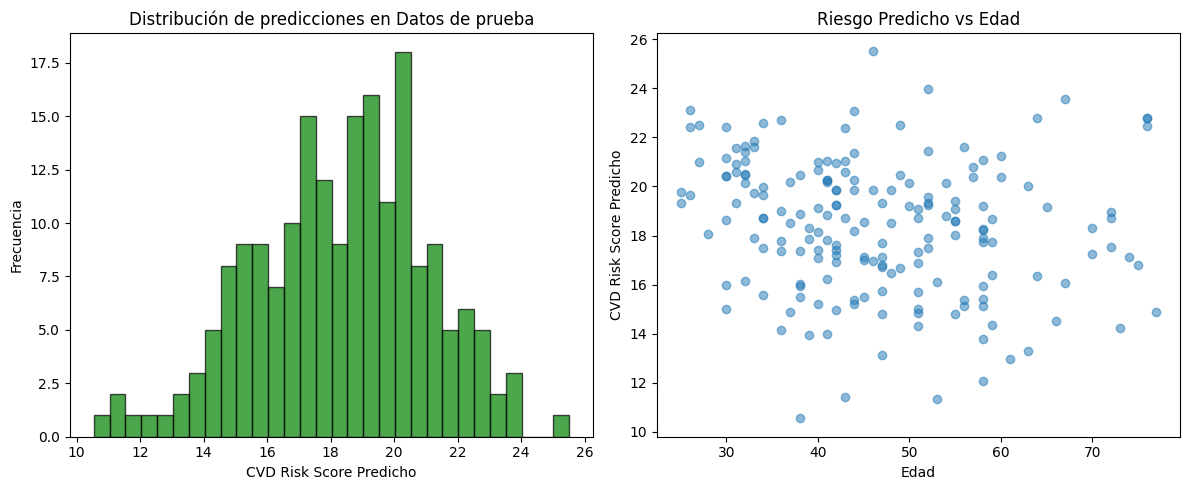

In [14]:
if mejor_idx == 0:
    X_test_datos = data_test[variables_numericas].copy()
    X_test_datos_prep = prep_m1.transform(X_test_datos)
    predicciones_test = modelo1.predict(X_test_datos_prep)
else: 
    X_test_datos = data_test.copy()
    X_test_datos_prep = prep_m2.transform(X_test_datos)
    predicciones_test = modelo2.predict(X_test_datos_prep)
    
data_test_con_predicciones = data_test.copy()
data_test_con_predicciones["CVD Risk Score"] = predicciones_test

print(f"Predicciones realizadas para {len(predicciones_test)} registros sin etiquetar")
print(f"Estadisticas de predicciones:")
print(f"Mínimo: {predicciones_test.min():.4f}")
print(f"Máximo: {predicciones_test.max():.4f}")
print(f"Media: {predicciones_test.mean():.4f}")
print(f"Desviación Estándar: {predicciones_test.std():.4f}")
print()

print("Primeras 10 predicciones: ")
print(data_test_con_predicciones[["Patient ID", "Age", "BMI", "CVD Risk Score"]].head(10))
print()

data_test_con_predicciones.to_csv("Datos Test Lab 1.csv", index=False, sep=";")
print("Archivo 'Datos Test Lab 1.csv' guardado con predicciones")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(predicciones_test, bins=30, edgecolor="black", alpha=0.7, color="green")
plt.xlabel("CVD Risk Score Predicho")
plt.ylabel("Frecuencia")
plt.title("Distribución de predicciones en Datos de prueba")
plt.subplot(1, 2, 2)
plt.scatter(data_test_con_predicciones['Age'], predicciones_test, alpha=0.5)
plt.xlabel('Edad')
plt.ylabel('CVD Risk Score Predicho')
plt.title("Riesgo Predicho vs Edad")
plt.tight_layout()
plt.show()